In [5]:
!pip install -q ultralytics opencv-python scikit-image matplotlib pandas tqdm pyyaml kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.5 MB/s eta 0:00:00


In [32]:
import os
import numpy as np
import random

REPO_ROOT = "/content/Motion-Deblurring-Object-Detection"

CONFIG = {
    "project_root": "/content/motion_deblur_detection_project",
    "dataset_root": "/content/datasets",
    "download_dataset": True,
    "kaggle_dataset_slug": "rahulbhalley/gopro-deblur",
    "dataset_zip_path": "/content/datasets/gopro-deblur.zip",
    "dataset_extract_dir": "/content/datasets/gopro_deblur",

    "max_images_for_analysis": 120,

    "deblurring_method": "wiener",
    "psf_size": 15,
    "psf_angle": 0,
    "wiener_k": 0.01,
    "rl_iterations": 15,

    "pretrained_detector": "yolov8n.pt",
    "pseudo_label_conf": 0.35,
    "inference_conf": 0.25,
    "imgsz": 640,

    "train_fraction": 0.7,
    "val_fraction": 0.2,
    "test_fraction": 0.1,
    "epochs": 20,
    "batch": 8,
    "train_imgsz": 640,
    "workers": 2,
    "device": 0,   # change to "cpu" if needed

    "allowed_class_ids": None,
    "num_visual_examples": 4,
    "random_seed": 42
}

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

In [7]:
import os
import cv2
import math
import zipfile
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def is_image_file(name):
    return name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))

def run_cmd(cmd):
    print("RUN:", cmd)
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Command failed: {cmd}")

def compute_psnr_ssim(sharp_bgr, restored_bgr):
    sharp_rgb = cv2.cvtColor(sharp_bgr, cv2.COLOR_BGR2RGB)
    restored_rgb = cv2.cvtColor(restored_bgr, cv2.COLOR_BGR2RGB)
    psnr_value = compare_psnr(sharp_rgb, restored_rgb, data_range=255)
    ssim_value = compare_ssim(sharp_rgb, restored_rgb, channel_axis=2, data_range=255)
    return psnr_value, ssim_value

def show_triplet(blur_bgr, restored_bgr, sharp_bgr, title=""):
    blur_rgb = cv2.cvtColor(blur_bgr, cv2.COLOR_BGR2RGB)
    restored_rgb = cv2.cvtColor(restored_bgr, cv2.COLOR_BGR2RGB)
    sharp_rgb = cv2.cvtColor(sharp_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 5))
    plt.suptitle(title)

    plt.subplot(1, 3, 1)
    plt.imshow(blur_rgb)
    plt.title("Blurred")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(restored_rgb)
    plt.title("Deblurred")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sharp_rgb)
    plt.title("Sharp")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def find_candidate_dirs(root, target_name):
    matches = []
    for cur_root, dirs, _ in os.walk(root):
        for d in dirs:
            if d.lower() == target_name.lower():
                full = os.path.join(cur_root, d)
                if len(os.listdir(full)) > 0:
                    matches.append(full)
    return sorted(matches)

def pick_best_dir(dir_list):
    if not dir_list:
        return None
    for d in dir_list:
        if "train" in d.lower():
            return d
    return dir_list[0]

def collect_paired_images_from_nested(blur_dir, sharp_dir, max_images=None):
    blur_map = {}
    sharp_map = {}

    for cur_root, _, files in os.walk(blur_dir):
        for f in files:
            if is_image_file(f):
                blur_map[f] = os.path.join(cur_root, f)

    for cur_root, _, files in os.walk(sharp_dir):
        for f in files:
            if is_image_file(f):
                sharp_map[f] = os.path.join(cur_root, f)

    common = sorted(set(blur_map.keys()) & set(sharp_map.keys()))
    if max_images is not None:
        common = common[:max_images]

    pairs = []
    for f in common:
        pairs.append({
            "name": f,
            "blur_path": blur_map[f],
            "sharp_path": sharp_map[f]
        })
    return pairs

def build_motion_psf(length=15, angle=0, size=None):
    if size is None:
        size = length
    psf = np.zeros((size, size), dtype=np.float32)
    center = size // 2

    angle_rad = np.deg2rad(angle)
    dx = math.cos(angle_rad)
    dy = math.sin(angle_rad)

    x0 = center - (length // 2) * dx
    y0 = center - (length // 2) * dy
    x1 = center + (length // 2) * dx
    y1 = center + (length // 2) * dy

    cv2.line(psf, (int(round(x0)), int(round(y0))), (int(round(x1)), int(round(y1))), 1, 1)
    s = psf.sum()
    if s > 0:
        psf /= s
    return psf

In [10]:
import os
import zipfile
import shutil
import subprocess # Added for run_cmd
from tqdm import tqdm

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def run_cmd(cmd):
    print("RUN:", cmd)
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Command failed: {cmd}")

def find_candidate_dirs(root, target_name):
    matches = []
    for cur_root, dirs, _ in os.walk(root):
        for d in dirs:
            if d.lower() == target_name.lower():
                full = os.path.join(cur_root, d)
                if len(os.listdir(full)) > 0:
                    matches.append(full)
    return sorted(matches)

def pick_best_dir(dir_list):
    if not dir_list:
        return None
    for d in dir_list:
        if "train" in d.lower():
            return d
    return dir_list[0]

def setup_project_structure(cfg):
    root = cfg["project_root"]
    dirs = [
        root,
        os.path.join(root, "data"),
        os.path.join(root, "data", "blur"),
        os.path.join(root, "data", "sharp"),
        os.path.join(root, "data", "restored"),
        os.path.join(root, "annotations"),
        os.path.join(root, "annotations", "pseudo_labels"),
        os.path.join(REPO_ROOT, "results"),
        os.path.join(REPO_ROOT, "results", "metrics"),
        os.path.join(REPO_ROOT, "results", "figures"),
        os.path.join(REPO_ROOT, "results", "detection"),
        os.path.join(REPO_ROOT, "results", "analysis"),
        os.path.join(root, "training"),
        os.path.join(root, "training", "yolo_dataset"),
        os.path.join(REPO_ROOT, "docs"),
        os.path.join(REPO_ROOT, "logs"),
        os.path.join(REPO_ROOT, "logs", "ai_logs"),
        cfg["dataset_root"]
    ]
    for d in dirs:
        ensure_dir(d)

def write_readme(cfg):
    with open(os.path.join("/content/Motion-Deblurring-Object-Detection", "README.md"), "w", encoding="utf-8") as f:
        f.write("# Motion Deblurring + Object Detection Project\n")

def write_ai_log(cfg):
    with open(os.path.join("/content/Motion-Deblurring-Object-Detection", "logs", "ai_logs", "ai_usage_log.md"), "w", encoding="utf-8") as f:
        f.write("# AI Usage Log\n")

def write_ethics_notes(cfg):
    with open(os.path.join("/content/Motion-Deblurring-Object-Detection", "docs", "ethics.md"), "w", encoding="utf-8") as f:
        f.write("# Ethics, Licensing, and Bias Notes\n")

def download_kaggle_dataset(cfg):
    zip_path = cfg["dataset_zip_path"]
    extract_dir = cfg["dataset_extract_dir"]

    if not os.path.exists(zip_path):
        run_cmd(f'kaggle datasets download -d {cfg["kaggle_dataset_slug"]} -p {cfg["dataset_root"]}')

    if not os.path.exists(extract_dir):
        ensure_dir(extract_dir)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

def discover_gopro_paths(cfg):
    root = cfg["dataset_extract_dir"]
    blur_dirs = find_candidate_dirs(root, "blur")
    sharp_dirs = find_candidate_dirs(root, "sharp")

    blur_dir = pick_best_dir(blur_dirs)
    sharp_dir = pick_best_dir(sharp_dirs)

    if blur_dir is None or sharp_dir is None:
        raise ValueError("Could not find blur and sharp directories.")
    return blur_dir, sharp_dir

def stage_dataset_into_project(cfg, pairs):
    blur_out = os.path.join(cfg["project_root"], "data", "blur")
    sharp_out = os.path.join(cfg["project_root"], "data", "sharp")

    staged_pairs = []
    for item in tqdm(pairs, desc="Staging dataset"):
        name = item["name"]
        blur_dst = os.path.join(blur_out, name)
        sharp_dst = os.path.join(sharp_out, name)

        if not os.path.exists(blur_dst):
            shutil.copy2(item["blur_path"], blur_dst)
        if not os.path.exists(sharp_dst):
            shutil.copy2(item["sharp_path"], sharp_dst)

        staged_pairs.append({
            "name": name,
            "blur_path": blur_dst,
            "sharp_path": sharp_dst
        })

    return staged_pairs

def run_task1(cfg, collect_paired_images_from_nested):
    print("Running Task 1...")
    setup_project_structure(cfg)
    write_readme(cfg)
    write_ai_log(cfg)
    write_ethics_notes(cfg)

    if cfg["download_dataset"]:
        download_kaggle_dataset(cfg)

    blur_dir, sharp_dir = discover_gopro_paths(cfg)
    pairs = collect_paired_images_from_nested(
        blur_dir,
        sharp_dir,
        cfg["max_images_for_analysis"]
    )
    pairs = stage_dataset_into_project(cfg, pairs)

    print(f"Task 1 completed. Paired images: {len(pairs)}")
    return pairs

In [11]:
from utils import collect_paired_images_from_nested
from task1_setup import run_task1

pairs = run_task1(CONFIG, collect_paired_images_from_nested)

Running Task 1...
RUN: kaggle datasets download -d rahulbhalley/gopro-deblur -p /content/datasets
Dataset URL: https://www.kaggle.com/datasets/rahulbhalley/gopro-deblur
License(s): unknown




Staging dataset: 100%|██████████| 120/120 [00:00<00:00, 408.66it/s]

Task 1 completed. Paired images: 120


In [19]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
#from utils import build_motion_psf, compute_psnr_ssim, show_triplet

def wiener_deconvolution_channel(channel, psf, K=0.01):
    eps = 1e-8
    h, w = channel.shape

    psf_padded = np.zeros((h, w), dtype=np.float32)
    ph, pw = psf.shape
    psf_padded[:ph, :pw] = psf
    psf_padded = np.roll(psf_padded, -ph // 2, axis=0)
    psf_padded = np.roll(psf_padded, -pw // 2, axis=1)

    G = np.fft.fft2(channel.astype(np.float32))
    H = np.fft.fft2(psf_padded)
    H_conj = np.conj(H)

    F_hat = (H_conj / (np.abs(H) ** 2 + K + eps)) * G
    restored = np.fft.ifft2(F_hat)
    restored = np.abs(restored)
    return np.clip(restored, 0, 255).astype(np.uint8)

def wiener_deblur(image_bgr, psf, K=0.01):
    channels = cv2.split(image_bgr)
    out_channels = [wiener_deconvolution_channel(ch, psf, K) for ch in channels]
    return cv2.merge(out_channels)

def deblur_image(image_bgr, cfg):
    psf = build_motion_psf(cfg["psf_size"], cfg["psf_angle"], cfg["psf_size"])
    return wiener_deblur(image_bgr, psf, cfg["wiener_k"])

def run_task2(cfg, pairs):
    print("Running Task 2...")
    restored_dir = os.path.join(cfg["project_root"], "data", "restored")
    rows = []

    for item in tqdm(pairs, desc="Deblurring"):
        blur_img = cv2.imread(item["blur_path"])
        sharp_img = cv2.imread(item["sharp_path"])

        if blur_img is None or sharp_img is None:
            continue

        restored_img = deblur_image(blur_img, cfg)
        cv2.imwrite(os.path.join(restored_dir, item["name"]), restored_img)

        psnr_value, ssim_value = compute_psnr_ssim(sharp_img, restored_img)
        rows.append({
            "image": item["name"],
            "psnr": psnr_value,
            "ssim": ssim_value
        })

    df = pd.DataFrame(rows)
    csv_path = os.path.join("/content/Motion-Deblurring-Object-Detection", "results", "metrics", "task2_deblur_metrics.csv")
    df.to_csv(csv_path, index=False)

    print("Task 2 completed.")
    return df

def visualize_task2_examples(cfg, pairs):
    for item in pairs[:cfg["num_visual_examples"]]:
        blur_img = cv2.imread(item["blur_path"])
        sharp_img = cv2.imread(item["sharp_path"])
        restored_img = cv2.imread(os.path.join(cfg["project_root"], "data", "restored", item["name"]))
        if blur_img is None or sharp_img is None or restored_img is None:
            continue

        psnr_value, ssim_value = compute_psnr_ssim(sharp_img, restored_img)
        show_triplet(
            blur_img,
            restored_img,
            sharp_img,
            title=f"{item['name']} | PSNR={psnr_value:.2f}, SSIM={ssim_value:.4f}"
        )

Running Task 2...


Deblurring: 100%|██████████| 120/120 [01:37<00:00,  1.23it/s]


Task 2 completed.


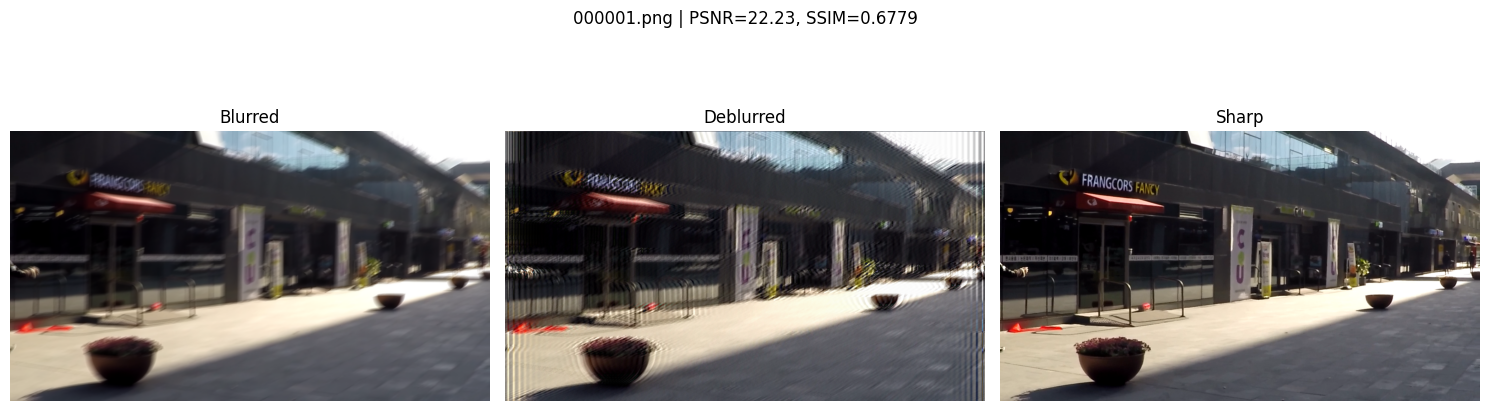

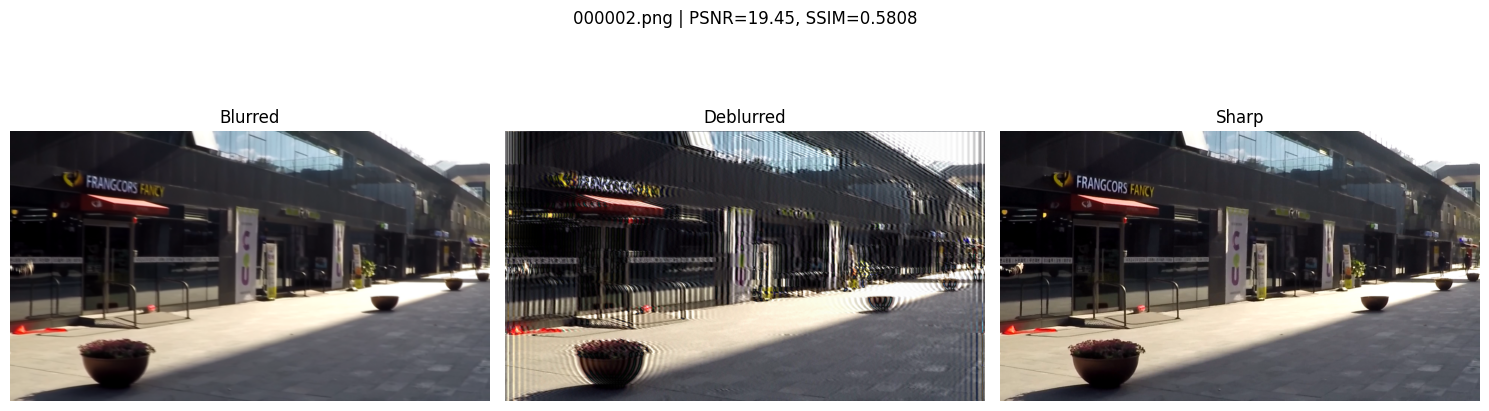

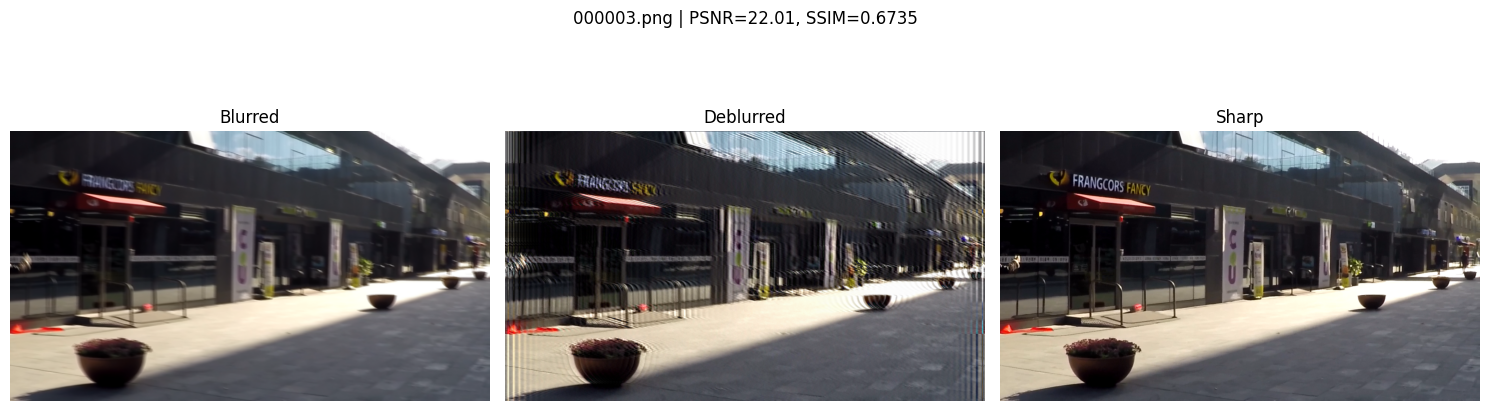

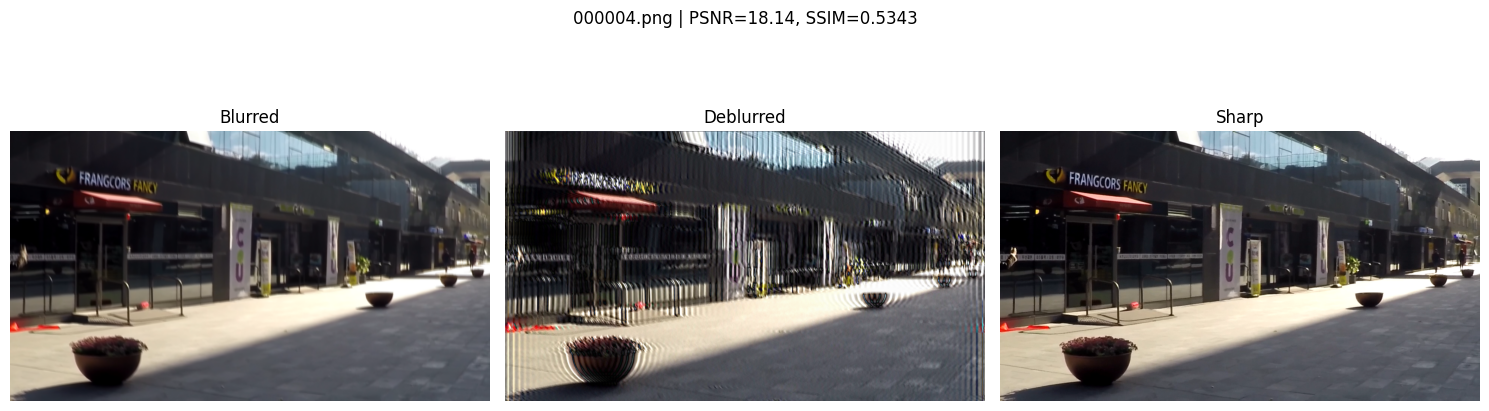

In [20]:
task2_df = run_task2(CONFIG, pairs)
visualize_task2_examples(CONFIG, pairs)

In [24]:
import os
import cv2
import time
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from ultralytics import YOLO

def load_detector(cfg):
    return YOLO(cfg["pretrained_detector"])

def parse_yolo_result(result):
    data = {
        "num_detections": 0,
        "mean_confidence": 0.0,
        "confidences": [],
        "classes": [],
        "boxes_xyxy": []
    }

    if result.boxes is None or len(result.boxes) == 0:
        return data

    confs = result.boxes.conf.cpu().numpy().tolist()
    classes = result.boxes.cls.cpu().numpy().astype(int).tolist()
    boxes = result.boxes.xyxy.cpu().numpy().tolist()

    data["num_detections"] = len(confs)
    data["mean_confidence"] = sum(confs) / len(confs) if confs else 0.0
    data["confidences"] = confs
    data["classes"] = classes
    data["boxes_xyxy"] = boxes
    return data

def run_single_inference(model, image_bgr, cfg):
    start = time.time()
    results = model.predict(source=image_bgr, conf=cfg["inference_conf"], imgsz=cfg["imgsz"], verbose=False)
    latency = time.time() - start
    result = results[0]
    parsed = parse_yolo_result(result)
    parsed["latency_sec"] = latency
    plotted = result.plot()
    return parsed, plotted

def xyxy_to_yolo(x1, y1, x2, y2, width, height):
    xc = ((x1 + x2) / 2.0) / width
    yc = ((y1 + y2) / 2.0) / height
    bw = (x2 - x1) / width
    bh = (y2 - y1) / height
    return xc, yc, bw, bh

def generate_pseudo_labels_from_sharp(cfg, pairs, detector):
    label_dir = os.path.join(cfg["project_root"], "annotations", "pseudo_labels")
    used_class_ids = set()
    class_name_map = detector.names

    for item in tqdm(pairs, desc="Generating pseudo labels"):
        img = cv2.imread(item["sharp_path"])
        if img is None:
            continue

        h, w = img.shape[:2]
        results = detector.predict(source=img, conf=cfg["pseudo_label_conf"], imgsz=cfg["imgsz"], verbose=False)
        result = results[0]

        label_lines = []
        if result.boxes is not None and len(result.boxes) > 0:
            confs = result.boxes.conf.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy().astype(int)
            boxes = result.boxes.xyxy.cpu().numpy()

            for conf, cls_id, box in zip(confs, classes, boxes):
                if cfg["allowed_class_ids"] is not None and cls_id not in cfg["allowed_class_ids"]:
                    continue

                x1, y1, x2, y2 = box.tolist()
                xc, yc, bw, bh = xyxy_to_yolo(x1, y1, x2, y2, w, h)
                label_lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
                used_class_ids.add(int(cls_id))

        with open(os.path.join(label_dir, Path(item["name"]).stem + ".txt"), "w", encoding="utf-8") as f:
            f.write("\n".join(label_lines))

    class_names = [class_name_map[c] for c in sorted(list(used_class_ids))]
    remap = {old_id: new_id for new_id, old_id in enumerate(sorted(list(used_class_ids)))}
    return class_names, remap

def remap_pseudo_label_files(cfg, remap):
    src_dir = os.path.join(cfg["project_root"], "annotations", "pseudo_labels")
    dst_dir = os.path.join(cfg["project_root"], "annotations", "pseudo_labels_remapped")
    os.makedirs(dst_dir, exist_ok=True)

    for f in os.listdir(src_dir):
        if not f.endswith(".txt"):
            continue

        src = os.path.join(src_dir, f)
        dst = os.path.join(dst_dir, f)

        new_lines = []
        with open(src, "r", encoding="utf-8") as fr:
            lines = [x.strip() for x in fr.readlines() if x.strip()]

        for line in lines:
            parts = line.split()
            old_id = int(parts[0])
            if old_id not in remap:
                continue
            new_id = remap[old_id]
            new_lines.append(" ".join([str(new_id)] + parts[1:]))

        with open(dst, "w", encoding="utf-8") as fw:
            fw.write("\n".join(new_lines))

    return dst_dir

def run_task3(cfg, pairs):
    print("Running Task 3...")
    detector = load_detector(cfg)
    restored_dir = os.path.join(cfg["project_root"], "data", "restored")
    det_dir = os.path.join("/content/Motion-Deblurring-Object-Detection", "results", "detection")

    rows = []
    for item in tqdm(pairs, desc="Detection analysis"):
        name = item["name"]
        blur_img = cv2.imread(item["blur_path"])
        sharp_img = cv2.imread(item["sharp_path"])
        restored_img = cv2.imread(os.path.join(restored_dir, name))

        if blur_img is None or sharp_img is None or restored_img is None:
            continue

        blur_stats, blur_vis = run_single_inference(detector, blur_img, cfg)
        restored_stats, restored_vis = run_single_inference(detector, restored_img, cfg)
        sharp_stats, sharp_vis = run_single_inference(detector, sharp_img, cfg)

        cv2.imwrite(os.path.join(det_dir, f"blur_{name}"), blur_vis)
        cv2.imwrite(os.path.join(det_dir, f"restored_{name}"), restored_vis)
        cv2.imwrite(os.path.join(det_dir, f"sharp_{name}"), sharp_vis)

        rows.extend([
            {"image": name, "domain": "blurred", "num_detections": blur_stats["num_detections"], "mean_confidence": blur_stats["mean_confidence"], "latency_sec": blur_stats["latency_sec"]},
            {"image": name, "domain": "deblurred", "num_detections": restored_stats["num_detections"], "mean_confidence": restored_stats["mean_confidence"], "latency_sec": restored_stats["latency_sec"]},
            {"image": name, "domain": "sharp", "num_detections": sharp_stats["num_detections"], "mean_confidence": sharp_stats["mean_confidence"], "latency_sec": sharp_stats["latency_sec"]}
        ])

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join("/content/Motion-Deblurring-Object-Detection", "results", "metrics", "task3_detection_comparison.csv"), index=False)

    class_names, remap = generate_pseudo_labels_from_sharp(cfg, pairs, detector)
    remapped_label_dir = remap_pseudo_label_files(cfg, remap)

    print("Task 3 completed.")
    return df, class_names, remapped_label_dir

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [25]:
task3_df, class_names, remapped_label_dir = run_task3(CONFIG, pairs)

Running Task 3...


Generating pseudo labels: 100%|██████████| 120/120 [00:04<00:00, 29.32it/s]

Task 3 completed.


In [30]:
import os
import cv2
import yaml
import shutil
import random
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO

def variance_of_laplacian(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def estimate_blur_level(image_bgr):
    score = variance_of_laplacian(image_bgr)
    if score < 20:
        return "high_blur", score
    elif score < 80:
        return "medium_blur", score
    return "low_blur", score

def stratify_images_by_blur(pairs):
    blur_groups = defaultdict(list)
    for item in pairs:
        img = cv2.imread(item["blur_path"])
        if img is None:
            continue
        level, score = estimate_blur_level(img)
        new_item = item.copy()
        new_item["blur_level"] = level
        new_item["blur_score"] = score
        blur_groups[level].append(new_item)
    return blur_groups

def split_list(items, train_frac, val_frac, test_frac, seed=42):
    items = items.copy()
    random.Random(seed).shuffle(items)

    n = len(items)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    return items[:n_train], items[n_train:n_train+n_val], items[n_train+n_val:]

def stratified_split(blur_groups, cfg):
    train_all, val_all, test_all = [], [], []
    for _, items in blur_groups.items():
        tr, va, te = split_list(items, cfg["train_fraction"], cfg["val_fraction"], cfg["test_fraction"], cfg["random_seed"])
        train_all.extend(tr)
        val_all.extend(va)
        test_all.extend(te)
    return train_all, val_all, test_all

def make_yolo_dirs(base):
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(base, "images", split), exist_ok=True)
        os.makedirs(os.path.join(base, "labels", split), exist_ok=True)

def copy_image_and_label(name, src_image, src_label, out_base, split):
    shutil.copy2(src_image, os.path.join(out_base, "images", split, name))
    dst_label = os.path.join(out_base, "labels", split, Path(name).stem + ".txt")
    if os.path.exists(src_label):
        shutil.copy2(src_label, dst_label)
    else:
        open(dst_label, "w").close()

def prepare_restored_yolo_dataset(cfg, train_items, val_items, test_items, class_names, remapped_label_dir):
    restored_dir = os.path.join(cfg["project_root"], "data", "restored")
    out_base = os.path.join(cfg["project_root"], "training", "yolo_dataset")
    make_yolo_dirs(out_base)

    for split_name, items in [("train", train_items), ("val", val_items), ("test", test_items)]:
        for item in tqdm(items, desc=f"Preparing {split_name} set"):
            name = item["name"]
            src_img = os.path.join(restored_dir, name)
            src_lbl = os.path.join(remapped_label_dir, Path(name).stem + ".txt")
            copy_image_and_label(name, src_img, src_lbl, out_base, split_name)

    yaml_path = os.path.join(out_base, "dataset.yaml")
    dataset_yaml = {
        "path": out_base,
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {i: n for i, n in enumerate(class_names)}
    }

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(dataset_yaml, f, sort_keys=False)

    return yaml_path

def train_detector(cfg, dataset_yaml_path):
    model = YOLO(cfg["pretrained_detector"])
    return model.train(
        data=dataset_yaml_path,
        epochs=cfg["epochs"],
        imgsz=cfg["train_imgsz"],
        batch=cfg["batch"],
        workers=cfg["workers"],
        device=cfg["device"],
        project=os.path.join(cfg["project_root"], "training"),
        name="restored_detector",
        exist_ok=True
    )

def run_task4(cfg, pairs, class_names, remapped_label_dir):
    print("Running Task 4...")
    blur_groups = stratify_images_by_blur(pairs)
    train_items, val_items, test_items = stratified_split(blur_groups, cfg)

    dataset_yaml_path = prepare_restored_yolo_dataset(
        cfg, train_items, val_items, test_items, class_names, remapped_label_dir
    )
    train_detector(cfg, dataset_yaml_path)

    print("Task 4 completed.")
    return train_items, val_items, test_items, dataset_yaml_path

In [33]:
train_items, val_items, test_items, dataset_yaml_path = run_task4(
    CONFIG, pairs, class_names, remapped_label_dir
)

Running Task 4...


Preparing test set: 100%|██████████| 14/14 [00:00<00:00, 472.78it/s]


Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/motion_deblur_detection_project/training/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=restored_detector, nbs=64, nms=False, opset=None, optimize=False, optimiz

In [34]:
import os
import yaml
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from ultralytics import YOLO

def make_yolo_dirs(base):
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(base, "images", split), exist_ok=True)
        os.makedirs(os.path.join(base, "labels", split), exist_ok=True)

def copy_image_and_label(name, src_image, src_label, out_base, split):
    shutil.copy2(src_image, os.path.join(out_base, "images", split, name))
    dst_label = os.path.join(out_base, "labels", split, Path(name).stem + ".txt")
    if os.path.exists(src_label):
        shutil.copy2(src_label, dst_label)
    else:
        open(dst_label, "w").close()

def get_best_weights_path(cfg):
    path = os.path.join(cfg["project_root"], "training", "restored_detector", "weights", "best.pt")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Best weights not found: {path}")
    return path

def create_domain_eval_dataset(cfg, items, domain, class_names, remapped_label_dir):
    out_root = os.path.join(cfg["project_root"], "training", f"eval_{domain}")
    make_yolo_dirs(out_root)

    for item in tqdm(items, desc=f"Building eval set: {domain}"):
        name = item["name"]

        if domain == "blurred":
            src_img = item["blur_path"]
        elif domain == "deblurred":
            src_img = os.path.join(cfg["project_root"], "data", "restored", name)
        else:
            src_img = item["sharp_path"]

        src_lbl = os.path.join(remapped_label_dir, Path(name).stem + ".txt")
        copy_image_and_label(name, src_img, src_lbl, out_root, "test")

    yaml_path = os.path.join(out_root, "dataset.yaml")
    dataset_yaml = {
        "path": out_root,
        "train": "images/test",
        "val": "images/test",
        "test": "images/test",
        "names": {i: n for i, n in enumerate(class_names)}
    }

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(dataset_yaml, f, sort_keys=False)

    return yaml_path

def validate_weights_on_dataset(weights_path, dataset_yaml_path, cfg, run_name):
    model = YOLO(weights_path)
    return model.val(
        data=dataset_yaml_path,
        imgsz=cfg["train_imgsz"],
        device=cfg["device"],
        split="test",
        project=os.path.join("/content/Motion-Deblurring-Object-Detection", "results"),
        name=run_name,
        exist_ok=True
    )

def extract_metrics(metrics_obj):
    return {
        "precision": float(metrics_obj.box.mp),
        "recall": float(metrics_obj.box.mr),
        "mAP50": float(metrics_obj.box.map50),
        "mAP50_95": float(metrics_obj.box.map)
    }

def save_summary_table(cfg, rows):
    out_csv = os.path.join("/content/Motion-Deblurring-Object-Detection", "results", "analysis", "final_summary.csv")
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df

def plot_summary(df):
    for metric in [c for c in df.columns if c != "domain"]:
        plt.figure(figsize=(6, 4))
        plt.bar(df["domain"], df[metric])
        plt.title(f"{metric} across domains")
        plt.grid(axis="y", linestyle="--", alpha=0.4)
        plt.show()

def run_task5(cfg, test_items, class_names, remapped_label_dir):
    print("Running Task 5...")
    best_weights = get_best_weights_path(cfg)

    blurred_yaml = create_domain_eval_dataset(cfg, test_items, "blurred", class_names, remapped_label_dir)
    deblurred_yaml = create_domain_eval_dataset(cfg, test_items, "deblurred", class_names, remapped_label_dir)
    sharp_yaml = create_domain_eval_dataset(cfg, test_items, "sharp", class_names, remapped_label_dir)

    metrics_blur = validate_weights_on_dataset(best_weights, blurred_yaml, cfg, "eval_blurred")
    metrics_deblur = validate_weights_on_dataset(best_weights, deblurred_yaml, cfg, "eval_deblurred")
    metrics_sharp = validate_weights_on_dataset(best_weights, sharp_yaml, cfg, "eval_sharp")

    summary_df = save_summary_table(cfg, [
        {"domain": "blurred", **extract_metrics(metrics_blur)},
        {"domain": "deblurred", **extract_metrics(metrics_deblur)},
        {"domain": "sharp", **extract_metrics(metrics_sharp)}
    ])

    plot_summary(summary_df)
    print("Task 5 completed.")
    return summary_df

Running Task 5...


Building eval set: sharp: 100%|██████████| 14/14 [00:00<00:00, 1265.74it/s]

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3243.4±501.8 MB/s, size: 735.1 KB)


val: Scanning /content/motion_deblur_detection_project/training/eval_blurred/labels/test... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 420.1it/s 0.0s
val: New cache created: /content/motion_deblur_detection_project/training/eval_blurred/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1s/it 1.1s
                   all         14         75      0.836      0.701      0.843       0.63
                person         12         41      0.793      0.902      0.936      0.731
               handbag          2          5          1      0.264      0.714      0.419
                  bowl          8          9       0.74      0.636      0.732      0.585
          potted plant         12         20      0.811          1       0.99      0.785
Speed: 0.9ms preprocess, 9.7ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to /content/Motion-Deblurring-Object-Detection/results/eval_b

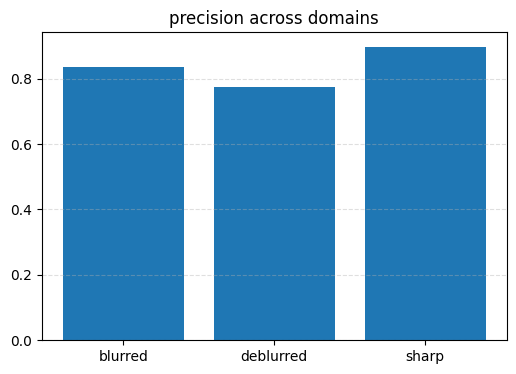

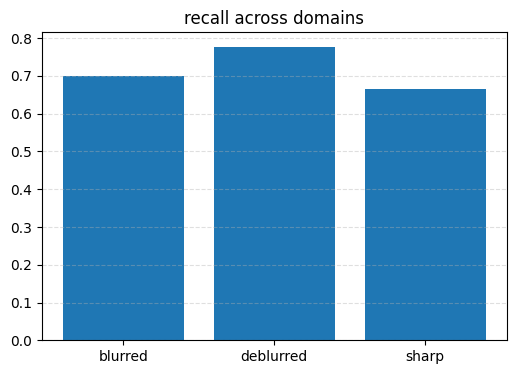

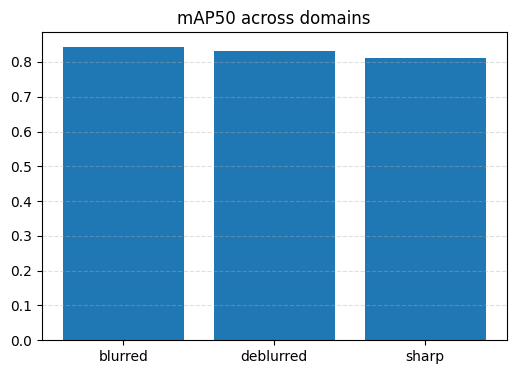

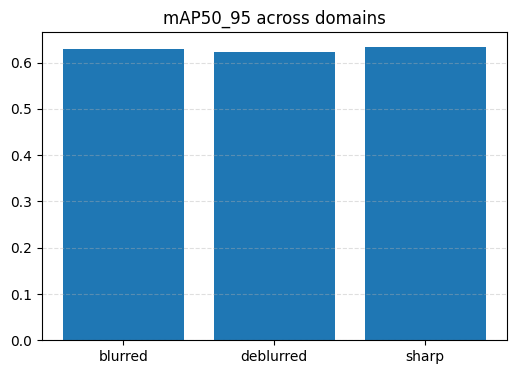

Task 5 completed.


In [35]:
summary_df = run_task5(
    CONFIG, test_items, class_names, remapped_label_dir
)